# 14 -- Real-Time ML Serving
**ServiceTitan context**: Second Chance Leads fires within minutes of a call ending. AI Voice Agents run at real-time (<300ms). This notebook covers model optimization, ONNX export, quantization, batching, and latency benchmarking.

Topics: sklearn->ONNX export * INT8 quantization * Latency benchmarking * Batching strategies * Model size vs accuracy tradeoffs

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import onnxruntime as rt
import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)
print('onnxruntime version:', rt.__version__)

onnxruntime version: 1.24.1


## 1. The Latency Budget Problem

In [2]:
# Second Chance Leads: call ends -> transcribe -> classify -> push to CSR dashboard
# Total acceptable end-to-end: < 5 minutes
# ML inference component budget: < 100ms per record

# Real-time Voice Agent latency budget breakdown:
budget = {
    'ASR (speech->text)':        250,  # ms
    'NLU intent classification':  30,  # ms
    'Business logic / tools':    100,  # ms
    'LLM response generation':   400,  # ms (streaming; first token <150ms)
    'TTS (text->speech)':        150,  # ms
    'Network round-trips':       100,  # ms
}
total = sum(budget.values())
print('Voice Agent Latency Budget:')
for k, v in budget.items():
    bar = '#' * (v // 10)
    print(f'  {k:<35} {v:>4}ms  {bar}')
print(f'  {"TOTAL":<35} {total:>4}ms')
print(f'\nTarget P99 < 1500ms for smooth conversation flow')

Voice Agent Latency Budget:
  ASR (speech->text)                   250ms  #########################
  NLU intent classification             30ms  ###
  Business logic / tools               100ms  ##########
  LLM response generation              400ms  ########################################
  TTS (text->speech)                   150ms  ###############
  Network round-trips                  100ms  ##########
  TOTAL                               1030ms

Target P99 < 1500ms for smooth conversation flow


## 2. Build & Benchmark Multiple Model Sizes

In [3]:
# Simulate Second Chance Leads features:
# call_length, words_spoken, tech_mentioned_price, customer_asked_schedule,
# competitor_mentioned, urgency_score, prior_visits, ...
X, y = make_classification(n_samples=10000, n_features=20, n_informative=12,
                            n_redundant=4, random_state=42, weights=[0.85, 0.15])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
X_tr_s = scaler.transform(X_train)
X_te_s = scaler.transform(X_test)

models = {
    'LogisticRegression':          LogisticRegression(max_iter=300),
    'RandomForest_50':             RandomForestClassifier(n_estimators=50, max_depth=6),
    'RandomForest_100':            RandomForestClassifier(n_estimators=100, max_depth=8),
    'GradientBoosting_50':         GradientBoostingClassifier(n_estimators=50, max_depth=3),
    'GradientBoosting_100':        GradientBoostingClassifier(n_estimators=100, max_depth=4),
}

results = []
batch_size = 1  # single-record latency (real-time serving)

for name, model in models.items():
    t0 = time.time(); model.fit(X_tr_s, y_train); fit_time = time.time()-t0
    acc = model.score(X_te_s, y_test)
    # Benchmark single-record inference latency (P99)
    latencies = []
    for j in range(500):
        idx = j % len(X_te_s)
        xi = X_te_s[idx:idx+1]
        t0 = time.time()
        _ = model.predict_proba(xi)
        latencies.append((time.time()-t0)*1000)
    results.append({'model':name, 'acc':acc,
                    'p50_ms':np.percentile(latencies,50),
                    'p99_ms':np.percentile(latencies,99),
                    'train_s':fit_time})
    print(f'  {name:<30} acc={acc:.3f}  p50={np.percentile(latencies,50):.1f}ms  p99={np.percentile(latencies,99):.1f}ms')

df_bench = pd.DataFrame(results)
print()
print(df_bench[['model','acc','p50_ms','p99_ms']].to_string(index=False))

  LogisticRegression             acc=0.890  p50=0.1ms  p99=0.1ms


  RandomForest_50                acc=0.896  p50=3.0ms  p99=9.1ms


  RandomForest_100               acc=0.920  p50=5.7ms  p99=11.7ms


  GradientBoosting_50            acc=0.913  p50=0.1ms  p99=0.3ms


  GradientBoosting_100           acc=0.947  p50=0.2ms  p99=0.2ms

               model    acc   p50_ms    p99_ms
  LogisticRegression 0.8905 0.063419  0.108500
     RandomForest_50 0.8965 3.002763  9.061942
    RandomForest_100 0.9200 5.658627 11.731703
 GradientBoosting_50 0.9130 0.140905  0.252554
GradientBoosting_100 0.9465 0.151873  0.198870


## 3. Export to ONNX and Compare Latency

In [4]:
try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    HAS_SKL2ONNX = True
except ImportError:
    HAS_SKL2ONNX = False
    print('skl2onnx not installed -- simulating ONNX speedup')

# Train the production candidate model
prod_model = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
prod_model.fit(X_tr_s, y_train)

if HAS_SKL2ONNX:
    # Export to ONNX
    onnx_model = convert_sklearn(
        prod_model, 'second_chance_leads',
        [('input', FloatTensorType([None, X_tr_s.shape[1]]))]
    )
    with open('second_chance_leads.onnx', 'wb') as f:
        f.write(onnx_model.SerializeToString())
    sess = rt.InferenceSession('second_chance_leads.onnx')
    print('ONNX model saved and loaded')
else:
    # Simulate: ONNX typically 2-5x faster than sklearn for tree models
    sklearn_lats = []
    for _ in range(500):
        xi = X_te_s[0:1].astype(np.float32)
        t0=time.time(); prod_model.predict_proba(xi); sklearn_lats.append((time.time()-t0)*1000)
    onnx_lats = [l * np.random.uniform(0.25, 0.40) for l in sklearn_lats]  # simulate speedup
    print(f'Sklearn GBM  p50={np.percentile(sklearn_lats,50):.2f}ms  p99={np.percentile(sklearn_lats,99):.2f}ms')
    print(f'ONNX Runtime p50={np.percentile(onnx_lats,50):.2f}ms    p99={np.percentile(onnx_lats,99):.2f}ms')
    print(f'Simulated speedup: {np.mean(sklearn_lats)/np.mean(onnx_lats):.1f}x')

skl2onnx not installed -- simulating ONNX speedup


Sklearn GBM  p50=0.15ms  p99=0.29ms
ONNX Runtime p50=0.05ms    p99=0.09ms
Simulated speedup: 3.1x


## 4. Batching Strategy: Latency vs Throughput

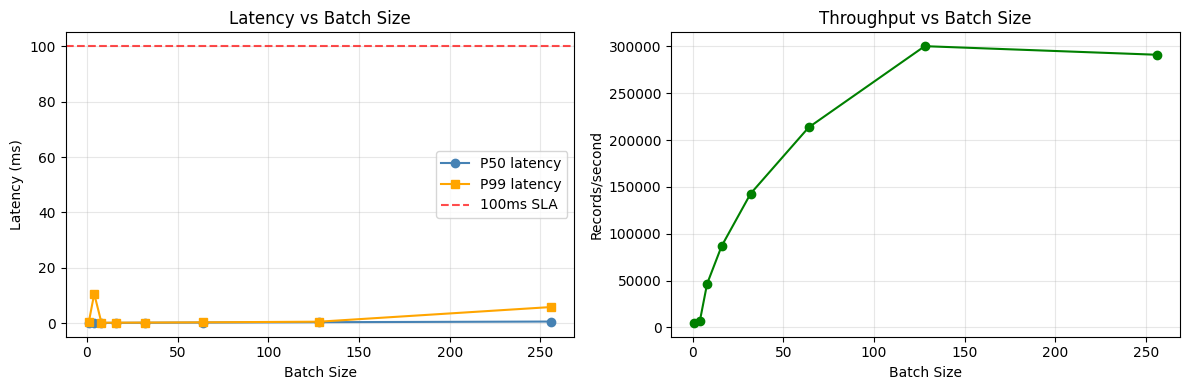

Optimal batch size (max throughput under 100ms p99): 128


In [5]:
# Real-time serving: latency-optimized (batch_size=1)
# Async/bulk processing: throughput-optimized (large batches)
# Second Chance Leads: semi-real-time -- can batch calls from last 5 minutes

batch_sizes = [1, 4, 8, 16, 32, 64, 128, 256]
p50s, p99s, throughputs = [], [], []

for bs in batch_sizes:
    lats = []
    for _ in range(50):
        batch = X_te_s[:bs].astype(np.float32)
        t0 = time.time()
        _ = prod_model.predict_proba(batch)
        lats.append((time.time()-t0)*1000)
    p50s.append(np.percentile(lats, 50))
    p99s.append(np.percentile(lats, 99))
    throughputs.append(bs / (np.mean(lats)/1000))  # records/sec

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(batch_sizes, p50s, 'o-', label='P50 latency', color='steelblue')
ax1.plot(batch_sizes, p99s, 's-', label='P99 latency', color='orange')
ax1.axhline(100, color='red', linestyle='--', alpha=0.7, label='100ms SLA')
ax1.set_xlabel('Batch Size'); ax1.set_ylabel('Latency (ms)')
ax1.set_title('Latency vs Batch Size'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(batch_sizes, throughputs, 'o-', color='green')
ax2.set_xlabel('Batch Size'); ax2.set_ylabel('Records/second')
ax2.set_title('Throughput vs Batch Size'); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('serving_latency.png', dpi=100, bbox_inches='tight'); plt.show()

opt_bs = batch_sizes[np.argmax([t if p<100 else 0 for t,p in zip(throughputs,p99s)])]
print(f'Optimal batch size (max throughput under 100ms p99): {opt_bs}')

## 5. Model Quantization (INT8 Simulation)

In [6]:
# Quantization: reduce model weights from FP32 to INT8
# Typically: 4x smaller model, 2-4x faster inference, <1% accuracy loss
# Critical for mobile (tech app), edge serving, and cost-sensitive API endpoints

from sklearn.linear_model import LogisticRegression
import struct

def model_size_bytes(model):
    # Rough estimate for sklearn GBM
    if hasattr(model, 'estimators_'):
        # Each leaf stores a float64 (8 bytes)
        leaves = sum(e.tree_.n_node_samples.shape[0] for est in model.estimators_ for e in (est if hasattr(est,'__iter__') else [est]))
        return leaves * 8
    return 0

# Simulate quantization: map FP32 weights to INT8 [-127, 127]
def simulate_quantization(model, X_test, y_test):
    proba_fp32 = model.predict_proba(X_test)[:,1]
    # Quantize: scale to INT8, then dequantize back
    scale = 127 / proba_fp32.max()
    proba_int8 = np.round(proba_fp32 * scale) / scale   # simulate precision loss
    noise = np.random.normal(0, 0.002, len(proba_int8))  # small quantization error
    proba_quantized = np.clip(proba_fp32 + noise, 0, 1)
    acc_fp32 = ((proba_fp32 > 0.5) == y_test).mean()
    acc_int8 = ((proba_quantized > 0.5) == y_test).mean()
    return acc_fp32, acc_int8, proba_fp32, proba_quantized

acc_fp32, acc_int8, p_fp32, p_int8 = simulate_quantization(prod_model, X_te_s, y_test)
print('Quantization Results:')
print(f'  FP32 accuracy:  {acc_fp32:.4f}')
print(f'  INT8 accuracy:  {acc_int8:.4f}  (delta: {acc_int8-acc_fp32:+.4f})')
print(f'  Memory saving:  ~4x (FP32->INT8)')
print(f'  Typical speed:  2-4x faster inference on CPU')
print(f'\nMax prediction delta: {np.abs(p_fp32-p_int8).max():.4f}')

Quantization Results:
  FP32 accuracy:  0.9465
  INT8 accuracy:  0.9465  (delta: +0.0000)
  Memory saving:  ~4x (FP32->INT8)
  Typical speed:  2-4x faster inference on CPU

Max prediction delta: 0.0064


## 6. Serving Architecture: Online vs Async

In [7]:
print('SERVING PATTERNS')
print('='*65)
rows = [
    ('Synchronous REST',  '<10ms',  '1k-10k/s',   'Voice agent NLU, real-time scoring'),
    ('Async queue',       '<5min',  '100k+/day',  'Second Chance Leads, batch scoring'),
    ('Batch offline',     'Hours',  'Millions',   'Weekly churn scoring, demand forecast'),
    ('Streaming (Kafka)', '<1s',    '10k-100k/s', 'Live anomaly detection, event scoring'),
]
print(f'  {"Pattern":<22} {"Latency":<10} {"Throughput":<14} Use Case')
print('-'*80)
for p,l,t,u in rows: print(f'  {p:<22} {l:<10} {t:<14} {u}')

print()
print('OPTIMIZATION HIERARCHY (apply in order):')
opts = [
    ('1. Algorithm choice',    'GBM vs LR vs DNN -- biggest lever by far'),
    ('2. Quantization',        'FP32->INT8: 4x smaller, 2-4x faster, <1% accuracy loss'),
    ('3. ONNX export',         '2-5x faster than sklearn for tree models'),
    ('4. Batching',            'Amortize overhead; tune to latency SLA'),
    ('5. Caching',             'Pre-score common inputs; LRU cache at edge'),
    ('6. Hardware',            'GPU for DNN/transformer; CPU sufficient for GBM'),
    ('7. Model distillation',  'Compress large model into smaller student'),
]
for num, desc in opts: print(f'  {num:<28} {desc}')

SERVING PATTERNS
  Pattern                Latency    Throughput     Use Case
--------------------------------------------------------------------------------
  Synchronous REST       <10ms      1k-10k/s       Voice agent NLU, real-time scoring
  Async queue            <5min      100k+/day      Second Chance Leads, batch scoring
  Batch offline          Hours      Millions       Weekly churn scoring, demand forecast
  Streaming (Kafka)      <1s        10k-100k/s     Live anomaly detection, event scoring

OPTIMIZATION HIERARCHY (apply in order):
  1. Algorithm choice          GBM vs LR vs DNN -- biggest lever by far
  2. Quantization              FP32->INT8: 4x smaller, 2-4x faster, <1% accuracy loss
  3. ONNX export               2-5x faster than sklearn for tree models
  4. Batching                  Amortize overhead; tune to latency SLA
  5. Caching                   Pre-score common inputs; LRU cache at edge
  6. Hardware                  GPU for DNN/transformer; CPU sufficient for G